# Point Sensors on a 2D Thermal Sheet

Click to open this example in \[[Github](https://github.com/Computer-Aided-Validation-Laboratory/pyvale/tree/main/src/pyvale/examples/ex1_1_thermal2d.ipynb)\] or try it out online without installation using: [![Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/Computer-Aided-Validation-Laboratory/pyvale/HEAD?urlpath=%2Fdoc%2Ftree%2Fsrc%2Fpyvale%2Fexamples%2Fex1_1_thermal2d.ipynb)

## About this Demo

This example demonstrates the construction of a set of thermal sensor on a two-dimensional thermal plate.

We demonstrate the `pyvale` module, the `sensor_array` factory, and how to use the dependencies of `pyvista` to visualise and plot results

## Setting Up Dependencies

Now we can import various libraries for the code we want to run for this particular notebook.

In [1]:
from pathlib import Path
import matplotlib.pyplot as plt
import mooseherder as mh
import pyvale

The following is for running in "Binder". It won't cause any issues if running this line locally. It changes the visualisation rendering mode from 'trame' to 'client' so that it will function over the cloud.

In [14]:
import pyvista as pv
pv.set_jupyter_backend('client')

## Load up a pre-existing pysics example

Pyvale provides a handful of pre-created physics simulations. Here, we want to measure and visualise the temperature difference on a two-dimensional sheet that has a difference in temperature across the surface.

This particular example is simulated at a very small scale, so we scale up the physical dimensions to make the visualisation clearer.

In [2]:
data_path = pyvale.DataSet.thermal_2d_output_path()
sim_data = mh.ExodusReader(data_path).read_all_sim_data()
field_key = "temperature"

# Scale to mm to make 3D visualisation scaling easier
sim_data.coords = sim_data.coords*1000.0


## Set up virtual temperature measurerers

Here we add a set of 6 virtual sensors across the thermal sheet.

We specify what sort of errors we want to attempt to model for the sensors. In this case we use `thermocouples_basic_errs` to simulate a small amount of random noise whenever the sensor samples the underlying temperature.

In [3]:
n_sens = (3,2,1)
x_lims = (0.0,100.0)
y_lims = (0.0,50.0)
z_lims = (0.0,0.0)
sens_pos = pyvale.create_sensor_pos_array(n_sens,x_lims,y_lims,z_lims)
sens_data = pyvale.SensorData(positions=sens_pos)

tc_array = pyvale.SensorArrayFactory \
	.thermocouples_basic_errs(sim_data,
								sens_data,
								field_key,
								spat_dims=2)

## Visualise the set-up

We can plot the thermal sheet as it looks at the final instance in time of the physics simulation

In [12]:
pv_plot = pyvale.plot_point_sensors_on_sim(tc_array,field_key)

# pre-determined camera position that shows the whole thermal sheet
pv_plot.camera_position = [(-7.547, 59.753, 134.52),
							(41.916, 25.303, 9.297),
							(0.0810, 0.969, -0.234)]
pv_plot.show()

Widget(value='<iframe src="http://localhost:41441/index.html?ui=P_0x7b5a7afdb490_3&reconnect=auto" class="pyvi…

## Visualise the recorded temperature

Finally, we can extract the temperature measurements for each of the created sensors and visualise the change

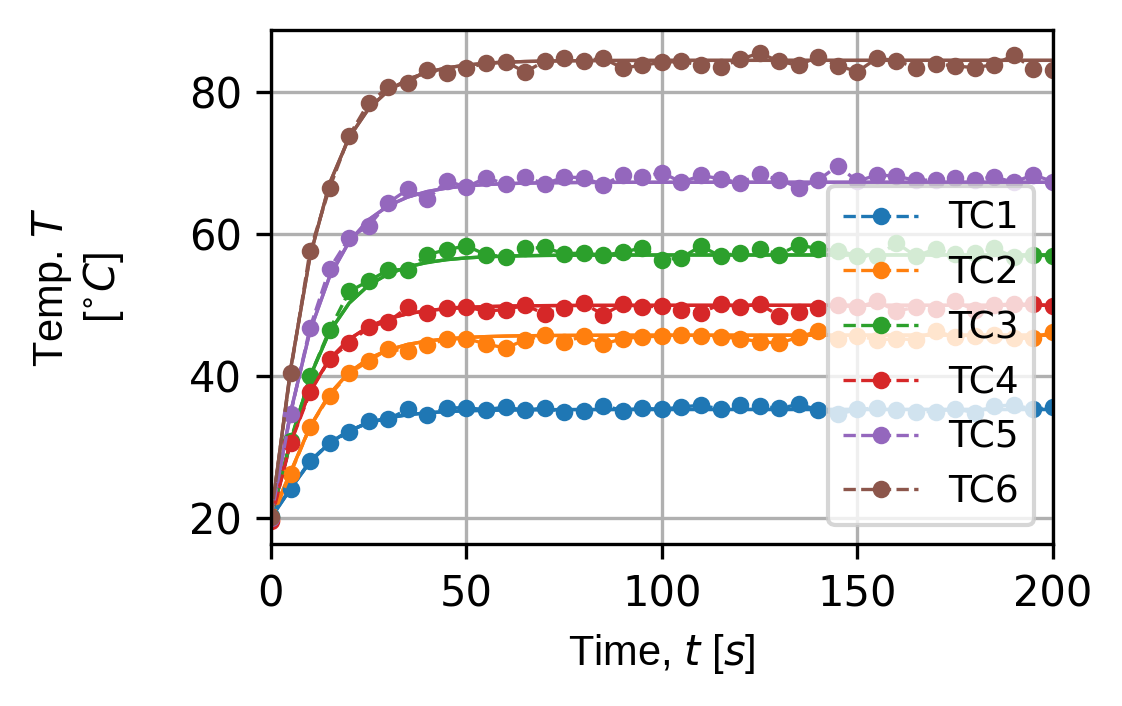

In [4]:
(fig,_) = pyvale.plot_time_traces(tc_array,field_key)
plt.show()

This figure shows a virtual representation of what real temperature sensors might see (circular dots) imposed with the real physical results (solid line) for each sensor.

The sheet starts at uniform temperature, as all the sensors read the same temperature at time t=0 (left of the graph). The thermal sheet reaches a thermal equilibrium after around t=50 seconds. The deviation of sampled points is determined by how we specify our errors. In this case, above, we used `thermocouples_basic_errs`